# Домашнее задание №8. Матрично-векторное дифференцирование. DL

## Ф.И.О: _________

В этом задании вам необходимо реализовать наиболее распространённые модули для построения глубоких нейронных сетей. Модули имеют структуру, подобную [torch](https://pytorch.org/).


## Module imports

In [ ]:
import numpy as np

## Testing imports

In [ ]:
import torch
from torch.autograd import Variable
from tqdm import tqdm

# Basic Module

**Module** is an abstract class which defines fundamental methods necessary for a training a neural network. **You do not need to change anything here, just read the comments.**

In [ ]:
class Module(object):
    """
    Basically, you can think of a module as of a something (black box)
    which can process `input` data and produce `ouput` data.
    This is like applying a function which is called `forward`:

        output = module.forward(input)

    The module should be able to perform a backward pass: to differentiate the `forward` function.
    More, it should be able to differentiate it if is a part of chain (chain rule).
    The latter implies there is a gradient from previous step of a chain rule.

        gradInput = module.backward(input, gradOutput)
    """
    def __init__ (self):
        self.output = None
        self.gradInput = None
        self.training = True

    def forward(self, input):
        """
        Takes an input object, and computes the corresponding output of the module.
        """
        return self.updateOutput(input)

    def backward(self,input, gradOutput):
        """
        Performs a backpropagation step through the module, with respect to the given input.

        This includes
         - computing a gradient w.r.t. `input` (is needed for further backprop),
         - computing a gradient w.r.t. parameters (to update parameters while optimizing).
        """
        self.updateGradInput(input, gradOutput)
        self.accGradParameters(input, gradOutput)
        return self.gradInput


    def updateOutput(self, input):
        """
        Computes the output using the current parameter set of the class and input.
        This function returns the result which is stored in the `output` field.

        Make sure to both store the data in `output` field and return it.
        """

        # The easiest case:

        # self.output = input
        # return self.output

        pass

    def updateGradInput(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own input.
        This is returned in `gradInput`. Also, the `gradInput` state variable is updated accordingly.

        The shape of `gradInput` is always the same as the shape of `input`.

        Make sure to both store the gradients in `gradInput` field and return it.
        """

        # The easiest case:

        # self.gradInput = gradOutput
        # return self.gradInput

        pass

    def accGradParameters(self, input, gradOutput):
        """
        Computing the gradient of the module with respect to its own parameters.
        No need to override if module has no parameters (e.g. ReLU).
        """
        pass

    def zeroGradParameters(self):
        """
        Zeroes `gradParams` variable if the module has params.
        """
        pass

    def getParameters(self):
        """
        Returns a list with its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def getGradParameters(self):
        """
        Returns a list with gradients with respect to its parameters.
        If the module does not have parameters return empty list.
        """
        return []

    def setParameters(self, parameters):
        pass

    def train(self):
        """
        Sets training mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = True

    def evaluate(self):
        """
        Sets evaluation mode for the module.
        Training and testing behaviour differs for Dropout, BatchNorm.
        """
        self.training = False

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Module"

# Layers

### __1__. Linear transform layer (0.5 point)

Also known as dense layer, fully-connected layer, FC-layer, InnerProductLayer (in caffe), affine transform
- input:   **`batch_size x n_feats1`**
- output: **`batch_size x n_feats2`**

In [ ]:
class Linear(Module):
    """
    A module which applies a linear transformation
    A common name is fully-connected layer, InnerProductLayer in caffe.

    The module should work with 2D input of shape (n_samples, n_feature).
    """
    def __init__(self, n_in, n_out):
        super(Linear, self).__init__()

        # This is a nice initialization
        stdv = 1./np.sqrt(n_in)
        self.W = np.random.uniform(-stdv, stdv, size = (n_out, n_in))
        self.b = np.random.uniform(-stdv, stdv, size = n_out)

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        # Your code goes here. ################################################
        # self.output = ...
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        # self.gradInput = ...
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        # Your code goes here. ################################################
        # self.gradW = ... ; self.gradb = ...
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def setParameters(self, parameters):
        self.W = parameters[0]
        self.b = parameters[1]

    def __repr__(self):
        s = self.W.shape
        q = 'Linear %d -> %d' %(s[1],s[0])
        return q

### Test Linear

In [ ]:
def test_Linear():
    batch_size, n_in, n_out = 2, 3, 4
    np.random.seed(42)
    torch.manual_seed(42)
    for _ in tqdm(range(100), desc="Testing Linear layer"):
        # layers initialization
        torch_layer = torch.nn.Linear(n_in, n_out)
        custom_layer = Linear(n_in, n_out)
        custom_layer.W = torch_layer.weight.data.numpy()
        custom_layer.b = torch_layer.bias.data.numpy()

        layer_input = np.random.uniform(-10, 10, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(-10, 10, (batch_size, n_out)).astype(np.float32)
        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

        # 3. check layer parameters grad
        custom_layer.accGradParameters(layer_input, next_layer_grad)
        weight_grad = custom_layer.gradW
        bias_grad = custom_layer.gradb
        torch_weight_grad = torch_layer.weight.grad.data.numpy()
        torch_bias_grad = torch_layer.bias.grad.data.numpy()
        np.testing.assert_allclose(
            torch_weight_grad, weight_grad, atol=3e-6,
            err_msg="Mismatch in weight gradients."
        )
        np.testing.assert_allclose(
            torch_bias_grad, bias_grad, atol=1e-6,
            err_msg="Mismatch in bias gradients."
        )


    print("\nAll tests passed successfully!")

test_Linear()

### __2__. SoftMax (1 point)

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{softmax}(x)_i = \frac{\exp x_i} {\sum_j \exp x_j}$

Recall that $\text{softmax}(x) == \text{softmax}(x - \text{const})$. It makes possible to avoid computing exp() from large argument.

In [ ]:
class SoftMax(Module):
    def __init__(self):
         super(SoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        return self.gradInput

    def __repr__(self):
        return "SoftMax"

### Test SoftMax

In [ ]:
def test_SoftMax():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing SoftMax layer"):
        # layers initialization
        torch_layer = torch.nn.Softmax(dim=1)
        custom_layer = SoftMax()

        layer_input = np.random.uniform(-10, 10, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.random((batch_size, n_in)).astype(np.float32)
        next_layer_grad /= next_layer_grad.sum(axis=-1, keepdims=True)
        next_layer_grad = next_layer_grad.clip(1e-5,1.)
        next_layer_grad = 1. / next_layer_grad

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-5,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1.5e-5,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_SoftMax()

### __3__. LogSoftMax (1 point)
- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

$\text{logsoftmax}(x)_i = \log\text{softmax}(x)_i = x_i - \log {\sum_j \exp x_j}$

The main goal of this layer is to be used in computation of log-likelihood loss.

In [ ]:
class LogSoftMax(Module):
    def __init__(self):
         super(LogSoftMax, self).__init__()

    def updateOutput(self, input):
        # start with normalization for numerical stability
        self.output = np.subtract(input, input.max(axis=1, keepdims=True))

        # Your code goes here. ################################################
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        return self.gradInput

    def __repr__(self):
        return "LogSoftMax"

### Test LogSoftMax

In [ ]:
def test_LogSoftMax():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing LogSoftMax layer"):
        # layers initialization
        torch_layer = torch.nn.LogSoftmax(dim=1)
        custom_layer = LogSoftMax()

        layer_input = np.random.uniform(-10, 10, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.random((batch_size, n_in)).astype(np.float32)
        next_layer_grad /= next_layer_grad.sum(axis=-1, keepdims=True)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )
        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_LogSoftMax()

### __4__. Batch normalization (1 point)

One of the most significant recent ideas that impacted NNs a lot is [**Batch normalization**](http://arxiv.org/abs/1502.03167). The idea is simple, yet effective: the features should be whitened ($mean = 0$, $std = 1$) all the way through NN. This improves the convergence for deep models letting it train them for days but not weeks. **You are** to implement the first part of the layer: features normalization. The second part (`ChannelwiseScaling` layer) is implemented below.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

The layer should work as follows. While training (`self.training == True`) it transforms input as $$y = \frac{x - \mu}  {\sqrt{\sigma + \epsilon}}$$
where $\mu$ and $\sigma$ - mean and variance of feature values in **batch** and $\epsilon$ is just a small number for numericall stability. Also during training, layer should maintain exponential moving average values for mean and variance:
```
    self.moving_mean = self.moving_mean * alpha + batch_mean * (1 - alpha)
    self.moving_variance = self.moving_variance * alpha + batch_variance * (1 - alpha)
```
During testing (`self.training == False`) the layer normalizes input using moving_mean and moving_variance.

Note that decomposition of batch normalization on normalization itself and channelwise scaling here is just a common **implementation** choice. In general "batch normalization" always assumes normalization + scaling.

In [ ]:
class BatchNormalization(Module):
    EPS = 1e-3
    def __init__(self, alpha = 0.):
        super(BatchNormalization, self).__init__()
        self.alpha = alpha
        self.moving_mean = None
        self.moving_variance = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        # use self.EPS please
        return self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        return self.gradInput

    def getParameters(self):
        return [self.moving_mean, self.moving_variance]

    def setParameters(self, parameters):
        self.moving_mean = parameters[0]
        self.moving_variance = parameters[1]

    def __repr__(self):
        return "BatchNormalization"

In [ ]:
class ChannelwiseScaling(Module):
    """
       Implements linear transform of input y = \gamma * x + \beta
       where \gamma, \beta - learnable vectors of length x.shape[-1]
    """
    def __init__(self, n_out):
        super(ChannelwiseScaling, self).__init__()

        stdv = 1./np.sqrt(n_out)
        self.gamma = np.random.uniform(-stdv, stdv, size=n_out)
        self.beta = np.random.uniform(-stdv, stdv, size=n_out)

        self.gradGamma = np.zeros_like(self.gamma)
        self.gradBeta = np.zeros_like(self.beta)

    def updateOutput(self, input):
        self.output = input * self.gamma + self.beta
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput * self.gamma
        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        self.gradBeta = np.sum(gradOutput, axis=0)
        self.gradGamma = np.sum(gradOutput*input, axis=0)

    def zeroGradParameters(self):
        self.gradGamma.fill(0)
        self.gradBeta.fill(0)

    def getParameters(self):
        return [self.gamma, self.beta]

    def getGradParameters(self):
        return [self.gradGamma, self.gradBeta]

    def setParameters(self, parameters):
        self.gamma = parameters[0]
        self.beta = parameters[1]

    def __repr__(self):
        return "ChannelwiseScaling"

Practical notes. If BatchNormalization is placed after a linear transformation layer (including dense layer, convolutions, channelwise scaling) that implements function like `y = weight * x + bias`, than bias adding become useless and could be omitted since its effect will be discarded while batch mean subtraction. If BatchNormalization (followed by `ChannelwiseScaling`) is placed before a layer that propagates scale (including ReLU, LeakyReLU) followed by any linear transformation layer than parameter `gamma` in `ChannelwiseScaling` could be freezed since it could be absorbed into the linear transformation layer.

### Test BatchNorm

In [ ]:
def test_BatchNormalization():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 32, 16
    for _ in tqdm(range(100), desc="Testing BacthNormalization layer"):
        # layers initialization
        slope = np.random.uniform(0.01, 0.05)
        alpha = 0.9
        custom_layer = BatchNormalization(alpha)
        custom_layer.train()
        torch_layer = torch.nn.BatchNorm1d(n_in, eps=custom_layer.EPS, momentum=1.-alpha, affine=False)
        custom_layer.moving_mean = torch_layer.running_mean.numpy().copy()
        custom_layer.moving_variance = torch_layer.running_var.numpy().copy()

        layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        # please, don't increase `atol` parameter, it's garanteed that you can implement batch norm layer
        # with tolerance 1e-5
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-5,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

        # 3. check moving mean
        np.testing.assert_allclose(
            torch_layer.running_mean.numpy(),
            custom_layer.moving_mean,
            atol=1e-8,
            err_msg="Mismatch in moving mean between torch and custom layer."
        )
        # we don't check moving_variance because pytorch uses slightly different formula for it:
        # it computes moving average for unbiased variance (i.e var*N/(N-1))
        # np.testing.assert_allclose(
        #     torch_layer.running_var.numpy(),
        #     custom_layer.moving_variance,
        #     atol=1e-8,
        #     err_msg="Mismatch in moving variance between torch and custom layer."
        # )

        # 4. check evaluation mode
        custom_layer.moving_variance = torch_layer.running_var.numpy().copy()
        custom_layer.evaluate()
        custom_layer_output = custom_layer.updateOutput(layer_input)
        torch_layer.eval()
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer in evaluation mode."
        )

    print("\nAll tests passed successfully!")

test_BatchNormalization()

### __5__. Dropout (3 point)

Implement [**dropout**](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf). The idea and implementation is really simple: just multimply the input by $Bernoulli(p)$ mask. Here $p$ is probability of an element to be zeroed.

This has proven to be an effective technique for regularization and preventing the co-adaptation of neurons.

While training (`self.training == True`) it should sample a mask on each iteration (for every batch), zero out elements and multiply elements by $1 / (1 - p)$. The latter is needed for keeping mean values of features close to mean values which will be in test mode. When testing this module should implement identity transform i.e. `self.output = input`.

- input:   **`batch_size x n_feats`**
- output: **`batch_size x n_feats`**

In [ ]:
class Dropout(Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()

        self.p = p
        self.mask = None

    def updateOutput(self, input):
        # Your code goes here. ################################################
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        return self.gradInput

    def getParameters(self):
        return [self.p, self.mask]

    def setParameters(self, parameters):
        self.p = parameters[0]
        self.mask = parameters[1]

    def __repr__(self):
        return "Dropout"

### Test Dropout

In [ ]:
def test_Dropout():
    np.random.seed(42)
    batch_size, n_in = 2, 4

    for _ in tqdm(range(100), desc="Testing Dropout layer"):
        # layers initialization
        p = np.random.uniform(0.3, 0.7)
        layer = Dropout(p)
        layer.train()

        layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)

        # 1. check layer output
        layer_output = layer.updateOutput(layer_input)
        mask = np.logical_or(np.isclose(layer_output, 0),
                             np.isclose(layer_output * (1. - p), layer_input))
        np.testing.assert_array_equal(mask, True), "Mismatch in dropout layer output."

        # 2. check layer input grad
        layer_grad = layer.updateGradInput(layer_input, next_layer_grad)
        mask_grad = np.logical_or(np.isclose(layer_grad, 0),
                                  np.isclose(layer_grad * (1. - p), next_layer_grad))
        np.testing.assert_array_equal(mask_grad, True), "Mismatch in dropout layer grad input."

        # 3. check evaluation mode
        layer.evaluate()
        layer_output = layer.updateOutput(layer_input)
        np.testing.assert_allclose(layer_output, layer_input, atol=1e-6), "Dropout evaluation mode failed."


        # 4. check mask
        p = 0.0
        layer = Dropout(p)
        layer.train()
        layer_output = layer.updateOutput(layer_input)
        np.testing.assert_allclose(layer_output, layer_input, atol=1e-6), "Dropout with p=0 should return input unchanged."

        p = 0.5
        layer = Dropout(p)
        layer.train()
        layer_input = np.random.uniform(5, 10, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(5, 10, (batch_size, n_in)).astype(np.float32)
        layer_output = layer.updateOutput(layer_input)
        zeroed_elem_mask = np.isclose(layer_output, 0)
        layer_grad = layer.updateGradInput(layer_input, next_layer_grad)
        np.testing.assert_array_equal(zeroed_elem_mask, np.isclose(layer_grad, 0)), "Mismatch in dropout mask."

        # 5. dropout mask should be generated independently for every input matrix element, not for row/column
        batch_size_large, n_in_large = 1000, 1
        p = 0.8
        layer = Dropout(p)
        layer.train()

        layer_input = np.random.uniform(5, 10, (batch_size_large, n_in_large)).astype(np.float32)
        layer_output = layer.updateOutput(layer_input)
        assert np.sum(np.isclose(layer_output, 0)) != layer_input.size, "Dropout mask should be applied independently."

        # Test with transposed input
        layer_input = layer_input.T
        layer_output = layer.updateOutput(layer_input)
        assert np.sum(np.isclose(layer_output, 0)) != layer_input.size, "Dropout mask should be applied independently for transposed input."

    print("\nAll tests passed successfully!")

test_Dropout()

# Sequential container

**Define** a forward and backward pass procedures.

In [ ]:
class Sequential(Module):
    """
         This class implements a container, which processes `input` data sequentially.

         `input` is processed by each module (layer) in self.modules consecutively.
         The resulting array is called `output`.
    """

    def __init__ (self):
        super(Sequential, self).__init__()
        self.modules = []

    def add(self, module):
        """
        Adds a module to the container.
        """
        self.modules.append(module)

    def updateOutput(self, input):
        """
        Basic workflow of FORWARD PASS:

            y_0    = module[0].forward(input)
            y_1    = module[1].forward(y_0)
            ...
            output = module[n-1].forward(y_{n-2})


        Just write a little loop.
        """

        # Your code goes here. ################################################
        return self.output

    def backward(self, input, gradOutput):
        """
        Workflow of BACKWARD PASS:

            g_{n-1} = module[n-1].backward(y_{n-2}, gradOutput)
            g_{n-2} = module[n-2].backward(y_{n-3}, g_{n-1})
            ...
            g_1 = module[1].backward(y_0, g_2)
            gradInput = module[0].backward(input, g_1)


        !!!

        To ech module you need to provide the input, module saw while forward pass,
        it is used while computing gradients.
        Make sure that the input for `i-th` layer the output of `module[i]` (just the same input as in forward pass)
        and NOT `input` to this Sequential module.

        !!!

        """
        # Your code goes here. ################################################
        return self.gradInput


    def zeroGradParameters(self):
        for module in self.modules:
            module.zeroGradParameters()

    def getGradParameters(self):
        """
        Should gather all gradients w.r.t parameters in a list.
        """
        return [x.getGradParameters() for x in self.modules]

    def setParameters(self, parameters):
        for x, parameter in zip(self.modules, parameters):
            x.setParameters(parameter)

    def getParameters(self):
        """
        Should gather all gradients w.r.t parameters in a list.
        """
        return [x.getParameters() for x in self.modules]

    def __repr__(self):
        string = "".join([str(x) + '\n' for x in self.modules])
        return string

    def __getitem__(self,x):
        return self.modules.__getitem__(x)

    def train(self):
        """
        Propagates training parameter through all modules
        """
        self.training = True
        for module in self.modules:
            module.train()

    def evaluate(self):
        """
        Propagates training parameter through all modules
        """
        self.training = False
        for module in self.modules:
            module.evaluate()

### Test Sequential

In [ ]:
def test_Sequential():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing Sequential layer"):
        # layers initialization
        alpha = 0.9
        torch_layer = torch.nn.BatchNorm1d(n_in, eps=BatchNormalization.EPS, momentum=1.-alpha, affine=True)
        torch_layer.bias.data = torch.from_numpy(np.random.random(n_in).astype(np.float32))
        custom_layer = Sequential()
        bn_layer = BatchNormalization(alpha)
        bn_layer.moving_mean = torch_layer.running_mean.numpy().copy()
        bn_layer.moving_variance = torch_layer.running_var.numpy().copy()
        custom_layer.add(bn_layer)
        scaling_layer = ChannelwiseScaling(n_in)
        scaling_layer.gamma = torch_layer.weight.data.numpy()
        scaling_layer.beta = torch_layer.bias.data.numpy()
        custom_layer.add(scaling_layer)
        custom_layer.train()

        layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=4e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.backward(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=2e-4,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

        # 3. check layer parameters grad
        weight_grad, bias_grad = custom_layer.getGradParameters()[1]
        torch_weight_grad = torch_layer.weight.grad.data.numpy()
        torch_bias_grad = torch_layer.bias.grad.data.numpy()
        np.testing.assert_allclose(
            torch_weight_grad, weight_grad, atol=2e-6,
            err_msg="Mismatch in weight gradients."
        )
        np.testing.assert_allclose(
            torch_bias_grad, bias_grad, atol=1e-6,
            err_msg="Mismatch in bias gradients."
        )

    print("\nAll tests passed successfully!")

test_Sequential()

# Activation functions

Here's the complete example for the **Rectified Linear Unit** non-linearity (aka **ReLU**):

In [ ]:
class ReLU(Module):
    def __init__(self):
         super(ReLU, self).__init__()

    def updateOutput(self, input):
        self.output = np.maximum(input, 0)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = np.multiply(gradOutput , input > 0)
        return self.gradInput

    def __repr__(self):
        return "ReLU"

### __6__. Leaky ReLU (1 point)

Implement [**Leaky Rectified Linear Unit**](http://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29%23Leaky_ReLUs). Expriment with slope.

In [ ]:
class LeakyReLU(Module):
    def __init__(self, slope = 0.03):
        super(LeakyReLU, self).__init__()

        self.slope = slope

    def updateOutput(self, input):
        # Your code goes here. ################################################
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        return self.gradInput

    def __repr__(self):
        return "LeakyReLU"

### Test Leaky ReLU

In [ ]:
def test_LeakyReLU():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing LeakyReLU layer"):
        # layers initialization
        slope = np.random.uniform(0.01, 0.05)
        torch_layer = torch.nn.LeakyReLU(slope)
        custom_layer = LeakyReLU(slope)

        layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_LeakyReLU()

### __7__. ELU (1 point)

Implement [**Exponential Linear Units**](http://arxiv.org/abs/1511.07289) activations.

In [ ]:
class ELU(Module):
    def __init__(self, alpha = 1.0):
        super(ELU, self).__init__()

        self.alpha = alpha

    def updateOutput(self, input):
        # Your code goes here. ################################################
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        return self.gradInput

    def __repr__(self):
        return "ELU"

### Test ELU

In [ ]:
def test_ELU():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing ELU layer"):
        # layers initialization
        alpha = 1.0
        torch_layer = torch.nn.ELU(alpha)
        custom_layer = ELU(alpha)

        layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_ELU()

### __8__. SoftPlus (1 point)

Implement [**SoftPlus**](https://en.wikipedia.org/wiki%2FRectifier_%28neural_networks%29) activations. Look, how they look a lot like ReLU.

In [ ]:
class SoftPlus(Module):
    def __init__(self):
        super(SoftPlus, self).__init__()

    def updateOutput(self, input):
        # Your code goes here. ################################################
        return  self.output

    def updateGradInput(self, input, gradOutput):
        # Your code goes here. ################################################
        return self.gradInput

    def __repr__(self):
        return "SoftPlus"

### Test SoftPlus

In [ ]:
def test_SoftPlus():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing SoftPlus layer"):
        # layers initialization
        torch_layer = torch.nn.Softplus()
        custom_layer = SoftPlus()

        layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
        next_layer_grad = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_SoftPlus()

# Criterions

Criterions are used to score the models answers.

In [ ]:
class Criterion(object):
    def __init__ (self):
        self.output = None
        self.gradInput = None

    def forward(self, input, target):
        """
            Given an input and a target, compute the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateOutput`.
        """
        return self.updateOutput(input, target)

    def backward(self, input, target):
        """
            Given an input and a target, compute the gradients of the loss function
            associated to the criterion and return the result.

            For consistency this function should not be overrided,
            all the code goes in `updateGradInput`.
        """
        return self.updateGradInput(input, target)

    def updateOutput(self, input, target):
        """
        Function to override.
        """
        return self.output

    def updateGradInput(self, input, target):
        """
        Function to override.
        """
        return self.gradInput

    def __repr__(self):
        """
        Pretty printing. Should be overrided in every module if you want
        to have readable description.
        """
        return "Criterion"

The **MSECriterion**, which is basic L2 norm usually used for regression, is implemented here for you.
- input:   **`batch_size x n_feats`**
- target: **`batch_size x n_feats`**
- output: **scalar**

In [ ]:
class MSECriterion(Criterion):
    def __init__(self):
        super(MSECriterion, self).__init__()

    def updateOutput(self, input, target):
        self.output = np.sum(np.power(input - target,2)) / input.shape[0]
        return self.output

    def updateGradInput(self, input, target):
        self.gradInput  = (input - target) * 2 / input.shape[0]
        return self.gradInput

    def __repr__(self):
        return "MSECriterion"

### __9__. Negative LogLikelihood criterion (numerically unstable) (1 point)

You task is to implement the **ClassNLLCriterion**. It should implement [multiclass log loss](http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss). Nevertheless there is a sum over `y` (target) in that formula,
remember that targets are one-hot encoded. This fact simplifies the computations a lot. Note, that criterions are the only places, where you divide by batch size. Also there is a small hack with adding small number to probabilities to avoid computing log(0).
- input:   **`batch_size x n_feats`** - probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**



In [ ]:
class ClassNLLCriterionUnstable(Criterion):
    EPS = 1e-15
    def __init__(self):
        a = super(ClassNLLCriterionUnstable, self)
        super(ClassNLLCriterionUnstable, self).__init__()

    def updateOutput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        return self.output

    def updateGradInput(self, input, target):

        # Use this trick to avoid numerical errors
        input_clamp = np.clip(input, self.EPS, 1 - self.EPS)

        # Your code goes here. ################################################
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterionUnstable"

### Test NLL (Unstable)

In [ ]:
def test_NLLCriterionUnstable():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing NLLCriterionUnstable layer"):
        # layers initialization
        torch_layer = torch.nn.NLLLoss()
        custom_layer = ClassNLLCriterionUnstable()

        layer_input = np.random.uniform(0, 1, (batch_size, n_in)).astype(np.float32)
        layer_input /= layer_input.sum(axis=-1, keepdims=True)
        layer_input = layer_input.clip(custom_layer.EPS, 1. - custom_layer.EPS)  # unifies input
        target_labels = np.random.choice(n_in, batch_size)
        target = np.zeros((batch_size, n_in), np.float32)
        target[np.arange(batch_size), target_labels] = 1  # one-hot encoding

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input, target)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(torch.log(layer_input_var),
                                                Variable(torch.from_numpy(target_labels), requires_grad=False))
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, target)
        torch_layer_output_var.backward()
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_NLLCriterionUnstable()

### __10__. Negative LogLikelihood criterion (numerically stable) (1 point)

- input:   **`batch_size x n_feats`** - log probabilities
- target: **`batch_size x n_feats`** - one-hot representation of ground truth
- output: **scalar**

Task is similar to the previous one, but now the criterion input is the output of log-softmax layer. This decomposition allows us to avoid problems with computation of forward and backward of log().

In [ ]:
class ClassNLLCriterion(Criterion):
    def __init__(self):
        a = super(ClassNLLCriterion, self)
        super(ClassNLLCriterion, self).__init__()

    def updateOutput(self, input, target):
        # Your code goes here. ################################################
        return self.output

    def updateGradInput(self, input, target):
        # Your code goes here. ################################################
        return self.gradInput

    def __repr__(self):
        return "ClassNLLCriterion"

### Test NLL (Stable)

In [ ]:
def test_NLLCriterion():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 4
    for _ in tqdm(range(100), desc="Testing NLLCriterion layer"):
        # layers initialization
        torch_layer = torch.nn.NLLLoss()
        custom_layer = ClassNLLCriterion()

        layer_input = np.random.uniform(-5, 5, (batch_size, n_in)).astype(np.float32)
        layer_input = torch.nn.LogSoftmax(dim=1)(Variable(torch.from_numpy(layer_input))).data.numpy()
        target_labels = np.random.choice(n_in, batch_size)
        target = np.zeros((batch_size, n_in), np.float32)
        target[np.arange(batch_size), target_labels] = 1  # one-hot encoding

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input, target)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var,
                                                Variable(torch.from_numpy(target_labels), requires_grad=False))
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, target)
        torch_layer_output_var.backward()
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_NLLCriterion()

# Optimizers

### SGD optimizer with momentum
- `variables` - list of lists of variables (one list per layer)
- `gradients` - list of lists of current gradients (same structure as for `variables`, one array for each var)
- `config` - dict with optimization parameters (`learning_rate` and `momentum`)
- `state` - dict with optimizator state (used to save accumulated gradients)

In [ ]:
def sgd_momentum(variables, gradients, config, state):
    # 'variables' and 'gradients' have complex structure, accumulated_grads will be stored in a simpler one
    state.setdefault('accumulated_grads', {})

    var_index = 0
    for current_layer_vars, current_layer_grads in zip(variables, gradients):
        for current_var, current_grad in zip(current_layer_vars, current_layer_grads):

            old_grad = state['accumulated_grads'].setdefault(var_index, np.zeros_like(current_grad))

            np.add(config['momentum'] * old_grad, config['learning_rate'] * current_grad, out=old_grad)

            current_var -= old_grad
            var_index += 1

### __11__. [Adam](https://arxiv.org/pdf/1412.6980.pdf) optimizer (1 point)

- `variables` - list of lists of variables (one list per layer)
- `gradients` - list of lists of current gradients (same structure as for `variables`, one array for each var)
- `config` - dict with optimization parameters (`learning_rate`, `beta1`, `beta2`, `epsilon`)
- `state` - dict with optimizator state (used to save 1st and 2nd moment for vars)

Formulas for optimizer:

Current step learning rate: $$\text{lr}_t = \text{learning-rate} * \frac{\sqrt{1-\beta_2^t}} {1-\beta_1^t}$$
First moment of var: $$\mu_t = \beta_1 * \mu_{t-1} + (1 - \beta_1)*g$$
Second moment of var: $$v_t = \beta_2 * v_{t-1} + (1 - \beta_2)*g*g$$
New values of var: $$\text{variable} = \text{variable} - \text{lr}_t * \frac{m_t}{\sqrt{v_t} + \epsilon}$$

In [ ]:
def adam_optimizer(variables, gradients, config, state):
    # 'variables' and 'gradients' have complex structure, accumulated_grads will be stored in a simpler one
    state.setdefault('m', {})  # first moment vars
    state.setdefault('v', {})  # second moment vars
    state.setdefault('t', 0)   # timestamp
    state['t'] += 1
    for k in ['learning_rate', 'beta1', 'beta2', 'epsilon']:
        assert k in config, config.keys()

    var_index = 0
    lr_t = config['learning_rate'] * np.sqrt(1 - config['beta2']**state['t']) / (1 - config['beta1']**state['t'])
    for current_layer_vars, current_layer_grads in zip(variables, gradients):
        for current_var, current_grad in zip(current_layer_vars, current_layer_grads):
            var_first_moment = state['m'].setdefault(var_index, np.zeros_like(current_grad))
            var_second_moment = state['v'].setdefault(var_index, np.zeros_like(current_grad))

            # <YOUR CODE> #######################################
            # update `current_var_first_moment`, `var_second_moment` and `current_var` values
            #np.add(... , out=var_first_moment)
            #np.add(... , out=var_second_moment)
            #current_var -= ...

            # small checks that you've updated the state; use np.add for rewriting np.arrays values
            assert var_first_moment is state['m'].get(var_index)
            assert var_second_moment is state['v'].get(var_index)
            var_index += 1


### Test Adam Optimizer

In [ ]:
def test_adam_optimizer():
    state = {}
    config = {'learning_rate': 1e-3, 'beta1': 0.9, 'beta2':0.999, 'epsilon':1e-8}
    variables = [[np.arange(10).astype(np.float64)]]
    gradients = [[np.arange(10).astype(np.float64)]]

    # First update
    adam_optimizer(variables, gradients, config, state)
    np.testing.assert_allclose(
        state['m'][0],
        np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
        err_msg="Mismatch in state['m'] after first update"
    )
    np.testing.assert_allclose(
        state['v'][0],
        np.array([0.0, 0.001, 0.004, 0.009, 0.016, 0.025, 0.036, 0.049, 0.064, 0.081]),
        err_msg="Mismatch in state['v'] after first update"
    )
    np.testing.assert_equal(
        state['t'],
        1,
        err_msg="Mismatch in state['t'] after first update"
    )
    np.testing.assert_allclose(
        variables[0][0],
        np.array([0.0, 0.999, 1.999, 2.999, 3.999, 4.999, 5.999, 6.999, 7.999, 8.999]),
        err_msg="Mismatch in variables after first update"
    )

    # Second update
    adam_optimizer(variables, gradients, config, state)
    np.testing.assert_allclose(
        state['m'][0],
        np.array([0.0, 0.19, 0.38, 0.57, 0.76, 0.95, 1.14, 1.33, 1.52, 1.71]),
        err_msg="Mismatch in state['m'] after second update"
    )
    np.testing.assert_allclose(
        state['v'][0],
        np.array([0.0, 0.001999, 0.007996, 0.017991, 0.031984, 0.049975, 0.071964, 0.097951, 0.127936, 0.161919]),
        err_msg="Mismatch in state['v'] after second update"
    )
    np.testing.assert_equal(
        state['t'],
        2,
        err_msg="Mismatch in state['t'] after second update"
    )
    np.testing.assert_allclose(
        variables[0][0],
        np.array([0.0, 0.998, 1.998, 2.998, 3.998, 4.998, 5.998, 6.998, 7.998, 8.998]),
        err_msg="Mismatch in variables after second update"
    )

    print("All tests passed successfully!")

test_adam_optimizer()

### __12__. (Доп.) Conv2d (1 point)

- input:   **`batch_size x in_channels x h x w`**
- output: **`batch_size x out_channels x h x w`**

You should implement something like pytorch `Conv2d` layer with `stride=1` and zero-padding outside of image using `scipy.signal.correlate` function.

Practical notes:
- While the layer name is "convolution", the most of neural network frameworks (including tensorflow and pytorch) implement operation that is called [correlation](https://en.wikipedia.org/wiki/Cross-correlation#Cross-correlation_of_deterministic_signals) in signal processing theory. So **don't use** `scipy.signal.convolve` since it implements [convolution](https://en.wikipedia.org/wiki/Convolution#Discrete_convolution) in terms of signal processing.
- It may be convenient to use `np.pad` for zero-padding.
- It's rather ok to implement convolution over 4d array using 2 nested loops: one over batch size dimension and another one over output filters dimension

In [ ]:
import scipy as sp
import scipy.signal

class Conv2d(Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super(Conv2d, self).__init__()
        assert kernel_size % 2 == 1, kernel_size

        stdv = 1./np.sqrt(in_channels)
        self.W = np.random.uniform(-stdv, stdv, size = (out_channels, in_channels, kernel_size, kernel_size))
        self.b = np.random.uniform(-stdv, stdv, size=(out_channels,))
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size

        self.gradW = np.zeros_like(self.W)
        self.gradb = np.zeros_like(self.b)

    def updateOutput(self, input):
        pad_size = self.kernel_size // 2
        # YOUR CODE ##############################
        # 1. zero-pad the input array
        # 2. compute convolution using scipy.signal.correlate(... , mode='valid')
        # 3. add bias value

        # self.output = ...

        return self.output

    def updateGradInput(self, input, gradOutput):
        pad_size = self.kernel_size // 2
        # YOUR CODE ##############################
        # 1. zero-pad the gradOutput
        # 2. compute 'self.gradInput' value using scipy.signal.correlate(... , mode='valid')

        # self.gradInput = ...

        return self.gradInput

    def accGradParameters(self, input, gradOutput):
        pad_size = self.kernel_size // 2
        # YOUR CODE #############
        # 1. zero-pad the input
        # 2. compute 'self.gradW' using scipy.signal.correlate(... , mode='valid')
        # 3. compute 'self.gradb' - formulas like in Linear of ChannelwiseScaling layers

        # self.gradW = ...
        # self.gradb = ...
        pass

    def zeroGradParameters(self):
        self.gradW.fill(0)
        self.gradb.fill(0)

    def getParameters(self):
        return [self.W, self.b]

    def getGradParameters(self):
        return [self.gradW, self.gradb]

    def setParameters(self, parameters):
        self.W = parameters[0]
        self.b = parameters[1]

    def __repr__(self):
        s = self.W.shape
        q = 'Conv2d %d -> %d' %(s[1],s[0])
        return q

### Test Conv2d

In [ ]:
def test_Conv2d():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in, n_out = 2, 3, 4
    h,w = 5,6
    kern_size = 3
    for _ in tqdm(range(100), desc="Testing Conv2d layer"):
        # layers initialization
        torch_layer = torch.nn.Conv2d(n_in, n_out, kern_size, padding=1)
        custom_layer = Conv2d(n_in, n_out, kern_size)
        custom_layer.W = torch_layer.weight.data.numpy() # [n_out, n_in, kern, kern]
        custom_layer.b = torch_layer.bias.data.numpy()

        layer_input = np.random.uniform(-1, 1, (batch_size, n_in, h,w)).astype(np.float32)
        next_layer_grad = np.random.uniform(-1, 1, (batch_size, n_out, h, w)).astype(np.float32)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )
        # 3. check layer parameters grad
        custom_layer.accGradParameters(layer_input, next_layer_grad)
        weight_grad = custom_layer.gradW
        bias_grad = custom_layer.gradb
        torch_weight_grad = torch_layer.weight.grad.data.numpy()
        torch_bias_grad = torch_layer.bias.grad.data.numpy()
        #m = ~np.isclose(torch_weight_grad, weight_grad, atol=1e-5)
        np.testing.assert_allclose(
            torch_weight_grad, weight_grad, atol=4e-6,
            err_msg="Mismatch in weight gradients."
        )
        np.testing.assert_allclose(
            torch_bias_grad, bias_grad, atol=4e-6,
            err_msg="Mismatch in bias gradients."
        )

    print("\nAll tests passed successfully!")

test_Conv2d()

### __13__. (Доп.) MaxPool2d (1 point)

- input:   **`batch_size x n_input_channels x h x w`**
- output: **`batch_size x n_output_channels x h // kern_size x w // kern_size`**

You are to implement simplified version of pytorch `MaxPool2d` layer with stride = kernel_size. Please note, that it's not a common case that stride = kernel_size: in AlexNet and ResNet kernel_size for max-pooling was set to 3, while stride was set to 2. We introduce this restriction to make implementation simplier.

Practical notes:
- During forward pass what you need to do is just to reshape the input tensor to `[n, c, h / kern_size, kern_size, w / kern_size, kern_size]`, swap two axes and take maximums over the last two dimensions. Reshape + axes swap is sometimes called space-to-batch transform.
- During backward pass you need to place the gradients in positions of maximal values taken during the forward pass
- In real frameworks the indices of maximums are stored in memory during the forward pass. It is cheaper than to keep the layer input in memory and recompute the maximums.

In [ ]:
class MaxPool2d(Module):
    def __init__(self, kernel_size):
        super(MaxPool2d, self).__init__()
        self.kernel_size = kernel_size
        self.gradInput = None

    def updateOutput(self, input):
        input_h, input_w = input.shape[-2:]
        # your may remove these asserts and implement MaxPool2d with padding
        assert input_h % self.kernel_size == 0
        assert input_w % self.kernel_size == 0

        # YOUR CODE #############################
        # self.output = ...
        # self.max_indices = ...
        return self.output

    def updateGradInput(self, input, gradOutput):
        # YOUR CODE #############################
        # self.gradInput = ...
        return self.gradInput

    def __repr__(self):
        q = 'MaxPool2d, kern %d, stride %d' %(self.kernel_size, self.kernel_size)
        return q

### Test MaxPool2d

In [ ]:
def test_MaxPool2d():
    np.random.seed(42)
    torch.manual_seed(42)

    batch_size, n_in = 2, 3
    h,w = 4,6
    kern_size = 2
    for _ in tqdm(range(100), desc="Testing MaxPool2d layer"):
        # layers initialization
        torch_layer = torch.nn.MaxPool2d(kern_size)
        custom_layer = MaxPool2d(kern_size)

        layer_input = np.random.uniform(-10, 10, (batch_size, n_in, h,w)).astype(np.float32)
        next_layer_grad = np.random.uniform(-10, 10, (batch_size, n_in,
                                                        h // kern_size, w // kern_size)).astype(np.float32)

        # 1. check layer output
        custom_layer_output = custom_layer.updateOutput(layer_input)
        layer_input_var = Variable(torch.from_numpy(layer_input), requires_grad=True)
        torch_layer_output_var = torch_layer(layer_input_var)
        np.testing.assert_allclose(
            torch_layer_output_var.data.numpy(),
            custom_layer_output,
            atol=1e-6,
            err_msg="Mismatch in forward output between torch and custom layer."
        )

        # 2. check layer input grad
        custom_layer_grad = custom_layer.updateGradInput(layer_input, next_layer_grad)
        torch_layer_output_var.backward(torch.from_numpy(next_layer_grad))
        torch_layer_grad_var = layer_input_var.grad
        np.testing.assert_allclose(
            torch_layer_grad_var.data.numpy(),
            custom_layer_grad,
            atol=1e-6,
            err_msg="Mismatch in gradient wrt input between torch and custom layer."
        )

    print("\nAll tests passed successfully!")

test_MaxPool2d()

### Flatten layer
Just reshapes inputs and gradients. It's usually used as proxy layer between Conv2d and Linear.

In [ ]:
class Flatten(Module):
    def __init__(self):
         super(Flatten, self).__init__()

    def updateOutput(self, input):
        self.output = input.reshape(len(input), -1)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(input.shape)
        return self.gradInput

    def __repr__(self):
        return "Flatten"

# Basic Artificial Neural Networks

We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework in ML.

In [1]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import gzip

In [2]:
import gdown

# download helper function
def download_with_shared_id(file_id, filename):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    gdown.download(url, filename, quiet=False)

## Framework

Implement everything in `Modules`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`.

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
```
You can use:
```
np.add(b,c,out = a) # puts result in `a`
```

## Digit classification

### Load dataset

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset.

In [3]:
def load_image(filename):
    # Read the inputs in Yann LeCun's binary format.
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    # The inputs are vectors now, we reshape them to monochrome 2D images
    data = data.reshape(-1, 28, 28)
    # The inputs come as bytes, we convert them to float32 in range [0,1].
    return (data / np.float32(256)).squeeze()

def load_mnist_labels(filename):
    # Read the labels in Yann LeCun's binary format.
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    # The labels are vectors of integers now, that's exactly what we want.
    return data

In [7]:
download_with_shared_id('1dUPLNohr1ncmS9inTIXZObGRcGraTEDt', 'train-images-idx3-ubyte.gz')
download_with_shared_id('1RpoolmS1B5UBFAUDRSlCM6Wmk1i_Ml6-', 'train-labels-idx1-ubyte.gz')
download_with_shared_id('1Qo5nJ93M1nkeLLYFYIog6ohGqnSlaSyT', 't10k-images-idx3-ubyte.gz')
download_with_shared_id('1Xcn6TNxuSI3A0PbDos3NUxgEfZha5ILq', 't10k-labels-idx1-ubyte.gz')

Downloading...
From: https://drive.google.com/uc?export=download&id=1dUPLNohr1ncmS9inTIXZObGRcGraTEDt
To: /content/train-images-idx3-ubyte.gz
100%|██████████| 9.91M/9.91M [00:00<00:00, 124MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1RpoolmS1B5UBFAUDRSlCM6Wmk1i_Ml6-
To: /content/train-labels-idx1-ubyte.gz
100%|██████████| 28.9k/28.9k [00:00<00:00, 39.5MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1Qo5nJ93M1nkeLLYFYIog6ohGqnSlaSyT
To: /content/t10k-images-idx3-ubyte.gz
100%|██████████| 1.65M/1.65M [00:00<00:00, 163MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1Xcn6TNxuSI3A0PbDos3NUxgEfZha5ILq
To: /content/t10k-labels-idx1-ubyte.gz
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.90MB/s]


In [8]:
X_train = load_image('train-images-idx3-ubyte.gz')
X_test = load_image('t10k-images-idx3-ubyte.gz')
Y_train = load_mnist_labels('train-labels-idx1-ubyte.gz')
Y_test = load_mnist_labels('t10k-labels-idx1-ubyte.gz')
# We reserve the last 10000 training examples for validation.
X_train, X_val = X_train[:-10000], X_train[-10000:]
Y_train, Y_val = Y_train[:-10000], Y_train[-10000:]

In [9]:
print('X_train: ' + str(X_train.shape))
print('Y_train: ' + str(Y_train.shape))
print('X_val: ' + str(X_val.shape))
print('Y_val: ' + str(Y_val.shape))
print('X_test:  '  + str(X_test.shape))
print('Y_test:  '  + str(Y_test.shape))

X_train: (50000, 28, 28)
Y_train: (50000,)
X_val: (10000, 28, 28)
Y_val: (10000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


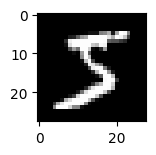


Y_train[0]: 5


In [10]:
plt.subplot(331)
plt.imshow(X_train[0], cmap=plt.get_cmap('gray'))
plt.show()
print()
print('Y_train[0]: ' + str(Y_train[0]))

## Preparing Data

### Task 1 (0.5 point):

make one-hot encoding for labels. Clue: use [np.eye](https://numpy.org/doc/stable/reference/generated/numpy.eye.html) for them

In [ ]:
def one_hot_encode(y):
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    one_hot_y = None
    return one_hot_y

hot_y_train = one_hot_encode(Y_train)
hot_y_val = one_hot_encode(Y_val)
hot_y_test = one_hot_encode(Y_test)

#### Test Task 1

In [ ]:
def one_hot_encode_test(hot_y_train):
    first_ten_answers = np.array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
                        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
                        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
                        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
                        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
                        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
                        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
                        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
                        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
                        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])
    np.testing.assert_equal(hot_y_train[:10], first_ten_answers, err_msg="First ten samples are not equal")
    print("The test pass successfully !!!")

one_hot_encode_test(hot_y_train)

### Task 2 (2.5 point):  

For CNN, we assume that images have size `(bs, num_channels, w, h)`. Our mnist image is grayscale, so, it don't have a `num_channels` dimension. You need to reshape `X_train`, `X_val` and `X_test` to apropriate size.

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
X_train, X_val, X_test = None, None, None

#### Test Task 2

In [ ]:
def dimension_test(X_train, X_val, X_test):
    true_train_shape = (50000, 784)
    true_test_shape = (10000, 784)
    np.testing.assert_equal(X_train.shape, true_train_shape, err_msg="Train shape doesn't the same")
    np.testing.assert_equal(X_val.shape, true_test_shape, err_msg="Train shape doesn't the same")
    np.testing.assert_equal(X_test.shape, true_test_shape, err_msg="Train shape doesn't the same")
    print("The test pass successfully !!!")

dimension_test(X_train, X_val, X_test)

### Compare activation function

- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions.
You would better pick the best optimizer params for each of them, but it is overkill for now.

- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.

- Fill blanks in the code below

- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.

- Hint: good logloss for MNIST should be around 0.5.

In [ ]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]

    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_idx = indices[start:end]
        yield X[batch_idx], Y[batch_idx]

In [ ]:
# Your code goes here.
def get_optimizer(optimizer_name):
    if optimizer_name == 'sgd_momentum':
        optimizer_config = # Your code goes here
        optimizer_state = {}

    elif optimizer_name == 'adam_optimizer':
        optimizer_config = # Your code goes here
        optimizer_state = {}

    else:
        raise NameError('Optimizer name have to one of {\'sgd_momentum\', \'adam_optimizer\'}')

    return optimizer_config, optimizer_state

In [ ]:
def train(net, criterion, optimizer_name, n_epoch,
          X_train, y_train, X_val, y_val, batch_size):

    loss_train_history = []
    loss_val_history = []
    optimizer_config, optimizer_state = get_optimizer(optimizer_name)

    for i in range(n_epoch):
        print('Epoch {}/{}:'.format(i, n_epoch - 1), flush=True)

        for phase in ['train', 'val']:
            if phase == 'train':
                X = X_train
                y = y_train
                net.train()
            else:
                X = X_val
                y = y_val
                net.evaluate()

            num_batches = X.shape[0] / batch_size
            running_loss = 0.
            running_acc = 0.

            for x_batch, y_batch in get_batches((X, y), batch_size):

                net.zeroGradParameters()

                # Forward
                predictions = # Your code goes here
                loss = # Your code goes here

                # Backward
                if phase == 'train':
                    # Your code goes here

                    # Update weights
                    if optimizer_name == 'sgd_momentum':
                        # Your code goes here
                    else:
                        # Your code goes here

                running_loss += loss
                running_acc += np.sum(predictions.argmax(axis=1) == y_batch.argmax(axis=1))

            epoch_loss = running_loss / num_batches
            epoch_acc = running_acc / y.shape[0]
            if phase == 'train':
                loss_train_history.append(epoch_loss)
            else:
                loss_val_history.append(epoch_loss)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc), flush=True)

    return net, loss_train_history, loss_val_history

In [ ]:
def test(net, criterion, X_test, y_test, batch_size):
    net.evaluate()
    num_batches = X_test.shape[0] / batch_size
    running_loss = 0.
    running_acc = 0.
    for x_batch, y_batch in get_batches((X_test, y_test), batch_size):
        net.zeroGradParameters()

        # Forward
        predictions = # Your code goes here
        loss = # Your code goes here
        running_loss += loss
        running_acc += (predictions.argmax(axis=1) == y_batch.argmax(axis=1)).astype(float).mean()

    epoch_loss = running_loss / num_batches
    epoch_acc = running_acc / num_batches
    return epoch_loss, epoch_acc

In [ ]:
def get_net(activation=ReLU, norm=False):
    net = Sequential()
    net.add(Linear(28*28, 100))
    if norm:
        net.add(BatchNormalization(alpha=0.0001))
        net.add(ChannelwiseScaling(100))
    net.add(activation())
    net.add(Linear(100, 10))
    if norm:
        net.add(BatchNormalization(alpha=0.0001))
        net.add(ChannelwiseScaling(10))
    net.add(LogSoftMax())
    return net

In [ ]:
# Fix parametrs (you can change it if you want)
batch_size = 64
n_epoch = 15
criterion = ClassNLLCriterion()
optimizer_name = 'sgd_momentum'

In [ ]:
nets = []
activations = # Your code goes here

for activ in activations:
    # Your code goes here
    # Add nets for all activation with or without Batch Normalization
    # Use `get_net` function

In [ ]:
losses_train = []
losses_val = []

for i, net in enumerate(nets):
    print(f'\n\nTrain net {i}/{len(nets)}')
    # Your code goes here
    # Train net and save net, losses on train and validation
    # Use `train` function
    # This may take up to 15 minutes

In [ ]:
for net in nets:
    # Your code goes here
    # Test net and print loss and accuracy
    # Use `test` function

In [ ]:
import matplotlib.pyplot as plt

# Your code goes here
# Plot train and validation loss for all nets

### Compare optimizer

- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?

In [ ]:
nets = []
optimizer_names = ['sgd_momentum', 'adam_optimizer']

for optim_name in optimizer_names:
    nets.append(get_net(activation=ReLU, norm=True))

In [ ]:
criterion = ClassNLLCriterion()
batch_size = 64
n_epoch = 15

losses_train = []
losses_val = []

for i, net in enumerate(nets):
    # Your code goes here
    # Train net and save net, losses on train and validation

In [ ]:
for net in nets:
    # Your code goes here
    # Test net and print loss and accuracy

In [ ]:
import matplotlib.pyplot as plt

# Your code goes here
# Plot train and validation loss for nets trained by sgd momentum and adam optimizer

What conclusions did you draw for yourself? Write your conclusion on the work done.

You can rely on the questions below:

- Which activation functions provide the best accuracy?

- Are there differences in training stability when using different activation functions?

- How does batch normalization affect the model's training speed?

- Does batch normalization improve the model's accuracy on the test dataset?

- How does batch normalization affect training stability?

- Which activation function provided the greatest improvement in performance when combined with batch normalization?

- How does the convergence speed of SGD with momentum compare to that of Adam?

- Are there differences in training stability when using SGD with momentum versus Adam?

- How does the loss function behave over epochs for each optimizer?

***Your answer here***:

### Task 3 (Доп.) Custom model (2 points)

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

In [ ]:
# Your code goes here
# Create a model

In [ ]:
# Your code goes here
# Train your custom architecture

In [ ]:
# Your code goes here
# Plot validation loss

Print here your accuracy on test set. It should be around 90%.

In [ ]:
# Your answer goes here

### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.
__Good Luck!__

In [ ]:
# Your beautiful code here

# Not So Basic Artificial Neural Networks

## CNN classification

### Task 4 (0.5 point):

You need to define `in_features` for the final linear layer based on `kernel_size` and `out_channels` variables.

In [ ]:
def create_cnn(kernel_size, out_channels):
    CNN = Sequential()
    CNN.add(Conv2d(in_channels = 1, out_channels = out_channels, kernel_size = kernel_size))
    CNN.add(MaxPool2d(kernel_size = kernel_size))
    CNN.add(ReLU())
    CNN.add(Flatten())

    # YOUR CODE HERE: Define `in_features` for variables `kernel_size`, `out_channels`
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    in_features = None
    CNN.add(Linear(in_features, 10))
    CNN.add(LogSoftMax())
    return CNN

#### Test task 4

In [ ]:
def test_cnn_creation():
    kernel_sizes = [1, 3, 5, 7]
    out_channels = [1, 2, 3, 4]
    rand_input = np.random.normal(size=(3, 1, 28, 28))
    try:
        rand_output = [create_cnn(ks, oc).forward(rand_input) for ks in kernel_sizes for oc in out_channels]
        print("The test pass successfully !!!")
    except Exception as e:
        print(e.message)
        raise AssertionError
test_cnn_creation()

### Task 5 (1 point)

You need to perform hyperparameter selection.

To narrow the search space, we fix `optimizer_name=sgd_momentum` and `batch_size=32`. So, there are neural network hyperparameters (`kernel_size` and `out_channels`) and optimizer's (`lr` and `momentum`).

See the structure of `sgd_momentum` to pass apropriate `optimizer_config` into `train` pipeline.

Since the pipeline was not defined for sklearn, using [`RandomSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) may be inapropriate. Use [`ParameterSampler`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterSampler.html) for them. The target criterion for selection is the validation loss.

A neural network from scratch does not involve computations using GPUs, so the training time for one epoch is significant. In this regard, use 3 runs of hyperparameter selection on 3 epochs (**It will take about 50 minutes.**).

In [ ]:
import numpy as np
from sklearn.model_selection import ParameterSampler

# YOUR CODE HERE: # Define the hyperparameter grid.
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
param_grid = None

# YOUR CODE HERE: # Define a list of parameters. The length of list is should equal to 3
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
param_list = None
assert len(param_list) == 3, f"We make a search only over 3 runs."

best_loss = np.inf
best_params = None
results = []
n_epoch = 3
batch_size = 32
criterion = ClassNLLCriterion()

for params in param_list:
    # YOUR CODE HERE:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    # 1. Create network with the given hyperparameters.
    net = None
    # 2. Build the optimizer configuration for sgd_momentum.
    optimizer_config = None


    # Run training.
    net, loss_train_history, loss_val_history = train(
        net, criterion, 'sgd_momentum', optimizer_config,
        n_epoch, X_train, hot_y_train, X_val, hot_y_val, batch_size
    )
    # The final epoch's validation loss as the metric.
    final_val_loss = loss_val_history[-1]
    results.append((params, final_val_loss))

    if final_val_loss < best_loss:
        best_loss = final_val_loss
        best_params = params

print("Best hyperparameters:", best_params)
print("Best validation loss: {:.4f}".format(best_loss))

### Task 6 (1 point)

For the selected hyperparameters, you need to run 3-fold cross-validation. Use [`KFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) for them (**It will also take about 50 minutes.**) \\
**Why is this necessary if we already make optimization over hyperparameter space?**

In [ ]:
from sklearn.model_selection import KFold

# YOUR CODE HERE:
# Define a KFold Class for cross-validaton.
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
kf = None

# YOUR CODE HERE:
# We need to merge images X_train and X_val
# and labels to make a random cross-validation
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
X_all = None
y_all = None

best_nn_weights = None
best_cv_loss = np.inf
cv_losses = []
n_epoch = 3
batch_size = 32
criterion = ClassNLLCriterion()

for fold, (train_index, val_index) in enumerate(kf.split(X_all)):
    # Split the full dataset into training and validation subsets for this fold.
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    X_train_cv, X_val_cv = None, None
    y_train_cv, y_val_cv = None, None

    # Create a new instance of the network and optimizer using best hyperparameters.
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    net = None
    optimizer_config = None

    # Train the model for this fold.
    net, loss_train_history, loss_val_history = train(
        net, criterion, 'sgd_momentum', optimizer_config,
        n_epoch, X_train_cv, y_train_cv, X_val_cv, y_val_cv, batch_size
    )

    # Record the final validation loss for this fold.
    fold_val_loss = loss_val_history[-1]

    # Save best final weights
    if fold_val_loss < best_cv_loss:
        best_cv_loss = fold_val_loss
        # getParameters of all modules in a sequential container.
        # clue: see the corresponding method in `Sequential` Module.
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        best_nn_weights = None

### Task 7 (1 point)

The final step is testing the model on a separate subset. Fill in the gaps in the `test` function. Initialize the neural network with the best hyperparameters and load the best weights.

In [ ]:
def test(net, criterion, X_test, y_test, batch_size):
    X_test, y_test = X_test[:3200], y_test[:3200]
    net.evaluate()
    num_batches = X_test.shape[0] / batch_size
    running_loss = 0.
    running_acc = 0.
    for x_batch, y_batch in get_batches((X_test, y_test), batch_size):
        net.zeroGradParameters()

        # Forward
        predictions = # Your code goes here
        loss = # Your code goes here
        running_loss += loss
        running_acc += (predictions.argmax(axis=1) == y_batch.argmax(axis=1)).astype(float).mean()

    epoch_loss = running_loss / num_batches
    epoch_acc = running_acc / num_batches
    print('Final Test Loss: {:.4f} Final Test Acc: {:.4f}'.format(epoch_loss, epoch_acc), flush=True)

    return epoch_loss, epoch_acc


###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
# 1. Init CNN with `best_params`
net = None
# setParameters of CNN with `best_nn_weights`.
# clue: see the corresponding method in `Sequential` Module.
None

epoch_loss, epoch_acc = test(net, criterion, X_test, hot_y_test, batch_size=32)

### Task 8 (1 point)

Now you need to apply your skills and creativity to improve the result:
1. Use more calculations (more detailed hyperparameter selection, more training epochs);
2. Create your own CNN with dropouts and batch normalization.

In [ ]:
from IPython.display import Image
Image(url='https://memepedia.ru/wp-content/uploads/2017/08/%D0%B1%D0%B5%D0%BD%D0%B4%D0%B5%D1%80-%D1%84%D1%83%D1%82%D1%83%D1%80%D0%B0%D0%BC%D0%B0.png', width=700)

3. Add augmentations to the training set.
4. Use adaptive optimization. Any other techniques are welcome!


At the output, you should get at least 97% on the test set.

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################